# UCI Hydraulic Condition Monitoring 데이터 전처리 및 모델 성능 분석
**HybridPdM - DenoisingAutoencoder 기반 유압 시스템 이상 탐지**

17개 다변량 센서(압력·전력·유량·온도·진동·효율) cycle별 평균 → AE 재구성 오차로 안정성 판정

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    f1_score, precision_score, recall_score, roc_auc_score
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

GREEN = '#3a9a5c'; RED = '#e05c5c'; BLUE = '#4a7fc1'; ORANGE = '#e8a838'

DATA_DIR = Path('../dataset/condition+monitoring+of+hydraulic+systems')
print('설정 완료')

설정 완료


---
## 01 데이터셋 로드 및 개요
17개 센서는 샘플레이트가 서로 다르다 (PS/EPS=100Hz, FS=10Hz, TS/VS/CE/CP/SE=1Hz). 본 분석은 각 cycle당 평균값으로 17차원 벡터를 만들어 단일 행으로 다룬다.

In [2]:
SENSORS = [
    'PS1','PS2','PS3','PS4','PS5','PS6',  # 압력 100Hz
    'EPS1',                                 # 전력 100Hz
    'FS1','FS2',                            # 유량 10Hz
    'TS1','TS2','TS3','TS4',                # 온도 1Hz
    'VS1',                                  # 진동 1Hz
    'CE','CP','SE',                         # 효율/파워/스와시 1Hz
]
SENSOR_GROUPS = {
    '압력 (100Hz)': ['PS1','PS2','PS3','PS4','PS5','PS6'],
    '전력 (100Hz)': ['EPS1'],
    '유량 (10Hz)':  ['FS1','FS2'],
    '온도 (1Hz)':   ['TS1','TS2','TS3','TS4'],
    '진동/효율':    ['VS1','CE','CP','SE'],
}

# 각 센서 파일 로드 → cycle별 평균
feats = {}
for s in SENSORS:
    arr = np.loadtxt(DATA_DIR / f'{s}.txt')
    if arr.ndim == 1: arr = arr.reshape(-1, 1)
    feats[s] = arr.mean(axis=1)
df = pd.DataFrame(feats)

# profile.txt: [cooler, valve, pump, hydraulic, stable]
profile = np.loadtxt(DATA_DIR / 'profile.txt', dtype=int)
df['stable_flag'] = profile[:, 4]
df['label'] = (profile[:, 4] == 0).astype(int)   # 1=이상(unstable), 0=정상(stable)

n_total = len(df); n_normal = int((df.label==0).sum()); n_anom = int((df.label==1).sum())
print(f'총 cycle: {n_total:,}')
print(f'  정상(stable):   {n_normal:,} ({n_normal/n_total*100:.1f}%)')
print(f'  이상(unstable): {n_anom:,}  ({n_anom/n_total*100:.1f}%)')
df.head()

총 cycle: 2,205
  정상(stable):   756 (34.3%)
  이상(unstable): 1,449  (65.7%)


,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,TS2,TS3,TS4,VS1,CE,CP,SE,stable_flag,label
0,160.673492,109.466914,1.991475,0.0,9.842169,9.728098,2538.929167,6.709815,10.304592,35.621983,40.978767,38.471017,31.745250,0.576950,39.601350,1.862750,59.157183,1,0
1,160.603320,109.354890,1.976234,0.0,9.635142,9.529488,2531.498900,6.715315,10.403098,36.676967,41.532767,38.978967,34.493867,0.565850,25.786433,1.255550,59.335617,1,0
2,160.347720,109.158845,1.972224,0.0,9.530548,9.427949,2519.928000,6.718522,10.366250,37.880800,42.442450,39.631950,35.646150,0.576533,22.218233,1.113217,59.543150,1,0
3,160.188088,109.064807,1.946576,0.0,9.438827,9.337429,2511.541633,6.720565,10.302678,38.879050,43.403983,40.403383,36.579467,0.569267,20.459817,1.062150,59.794900,1,0
4,160.000472,108.931434,1.922707,0.0,9.358762,9.260636,2503.449500,6.690308,10.237750,39.803917,44.332750,41.310550,37.427900,0.577367,19.787017,1.070467,59.455267,1,0


---
## 02 데이터 전처리 시각화

### 2-1. 클래스 분포 + 결함 유형별 분포 (profile 4컬럼)

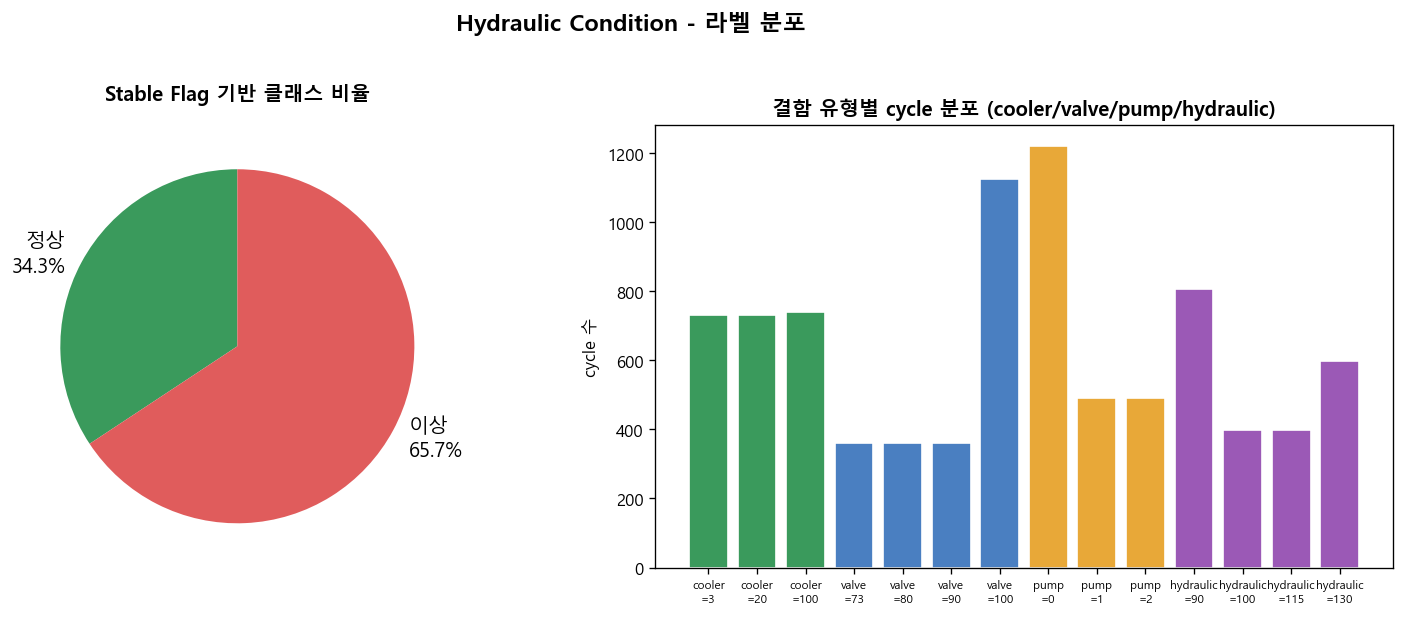

In [3]:
PROFILE_COLS = ['cooler','valve','pump','hydraulic','stable']
prof_df = pd.DataFrame(profile, columns=PROFILE_COLS)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 정상/이상 파이
ax = axes[0]
sizes = [n_normal, n_anom]
labels = [f'정상\n{n_normal/n_total*100:.1f}%', f'이상\n{n_anom/n_total*100:.1f}%']
ax.pie(sizes, labels=labels, colors=[GREEN, RED], startangle=90, textprops={'fontsize': 12})
ax.set_title('Stable Flag 기반 클래스 비율', fontweight='bold', pad=15)

# 4가지 결함 유형별 unique 값 분포
ax2 = axes[1]
fault_data = []
for col in PROFILE_COLS[:4]:
    uniq = prof_df[col].value_counts().sort_index()
    fault_data.append((col, uniq))

x_pos = 0
all_labels = []; all_counts = []; all_colors = []
palette = [GREEN, BLUE, ORANGE, '#9b59b6', RED]
for i, (col, uniq) in enumerate(fault_data):
    for j, (val, cnt) in enumerate(uniq.items()):
        all_labels.append(f'{col}\n={val}')
        all_counts.append(cnt)
        all_colors.append(palette[i % len(palette)])
ax2.bar(range(len(all_counts)), all_counts, color=all_colors, edgecolor='white')
ax2.set_xticks(range(len(all_counts)))
ax2.set_xticklabels(all_labels, fontsize=7, rotation=0)
ax2.set_title('결함 유형별 cycle 분포 (cooler/valve/pump/hydraulic)', fontweight='bold')
ax2.set_ylabel('cycle 수')

plt.suptitle('Hydraulic Condition - 라벨 분포', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 2-2. 센서 상관관계 히트맵 (17 × 17)

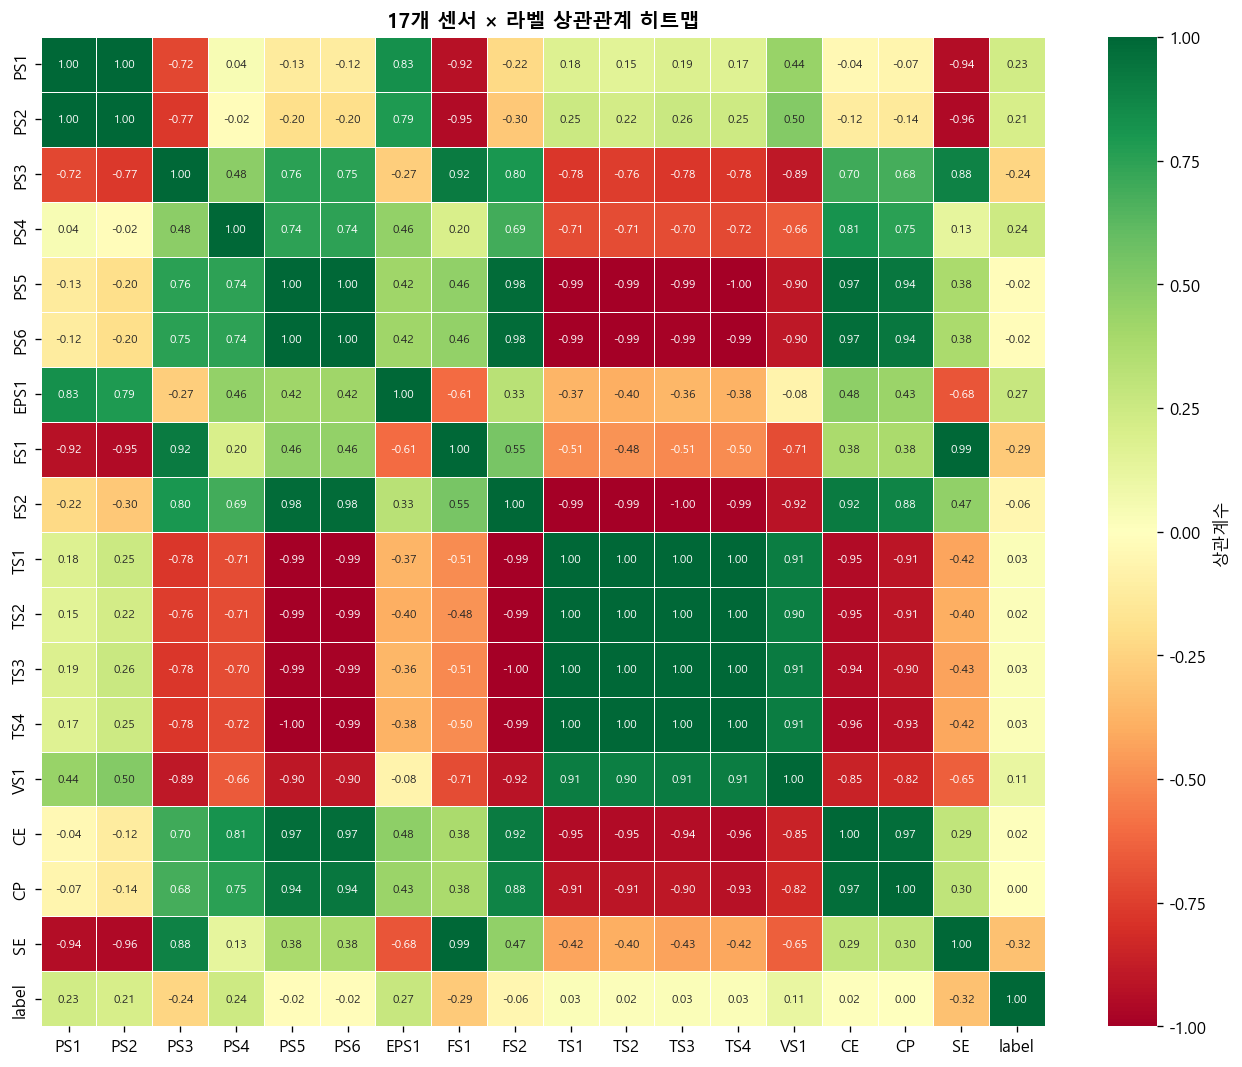


[label과 상관계수 절댓값 Top 5]
  SE: -0.325
  FS1: -0.289
  EPS1: +0.268
  PS4: +0.244
  PS3: -0.237


In [4]:
corr = df[SENSORS + ['label']].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            annot_kws={'size': 7}, cbar_kws={'label': '상관계수'})
ax.set_title('17개 센서 × 라벨 상관관계 히트맵', fontweight='bold')
plt.tight_layout(); plt.show()

# 라벨과 가장 상관 높은 센서 Top 5
top5 = corr['label'].abs().drop('label').sort_values(ascending=False).head(5)
print('\n[label과 상관계수 절댓값 Top 5]')
for s, c in top5.items():
    print(f'  {s}: {corr.loc[s, "label"]:+.3f}')

### 2-3. 센서 그룹별 분포 (정상 vs 이상)

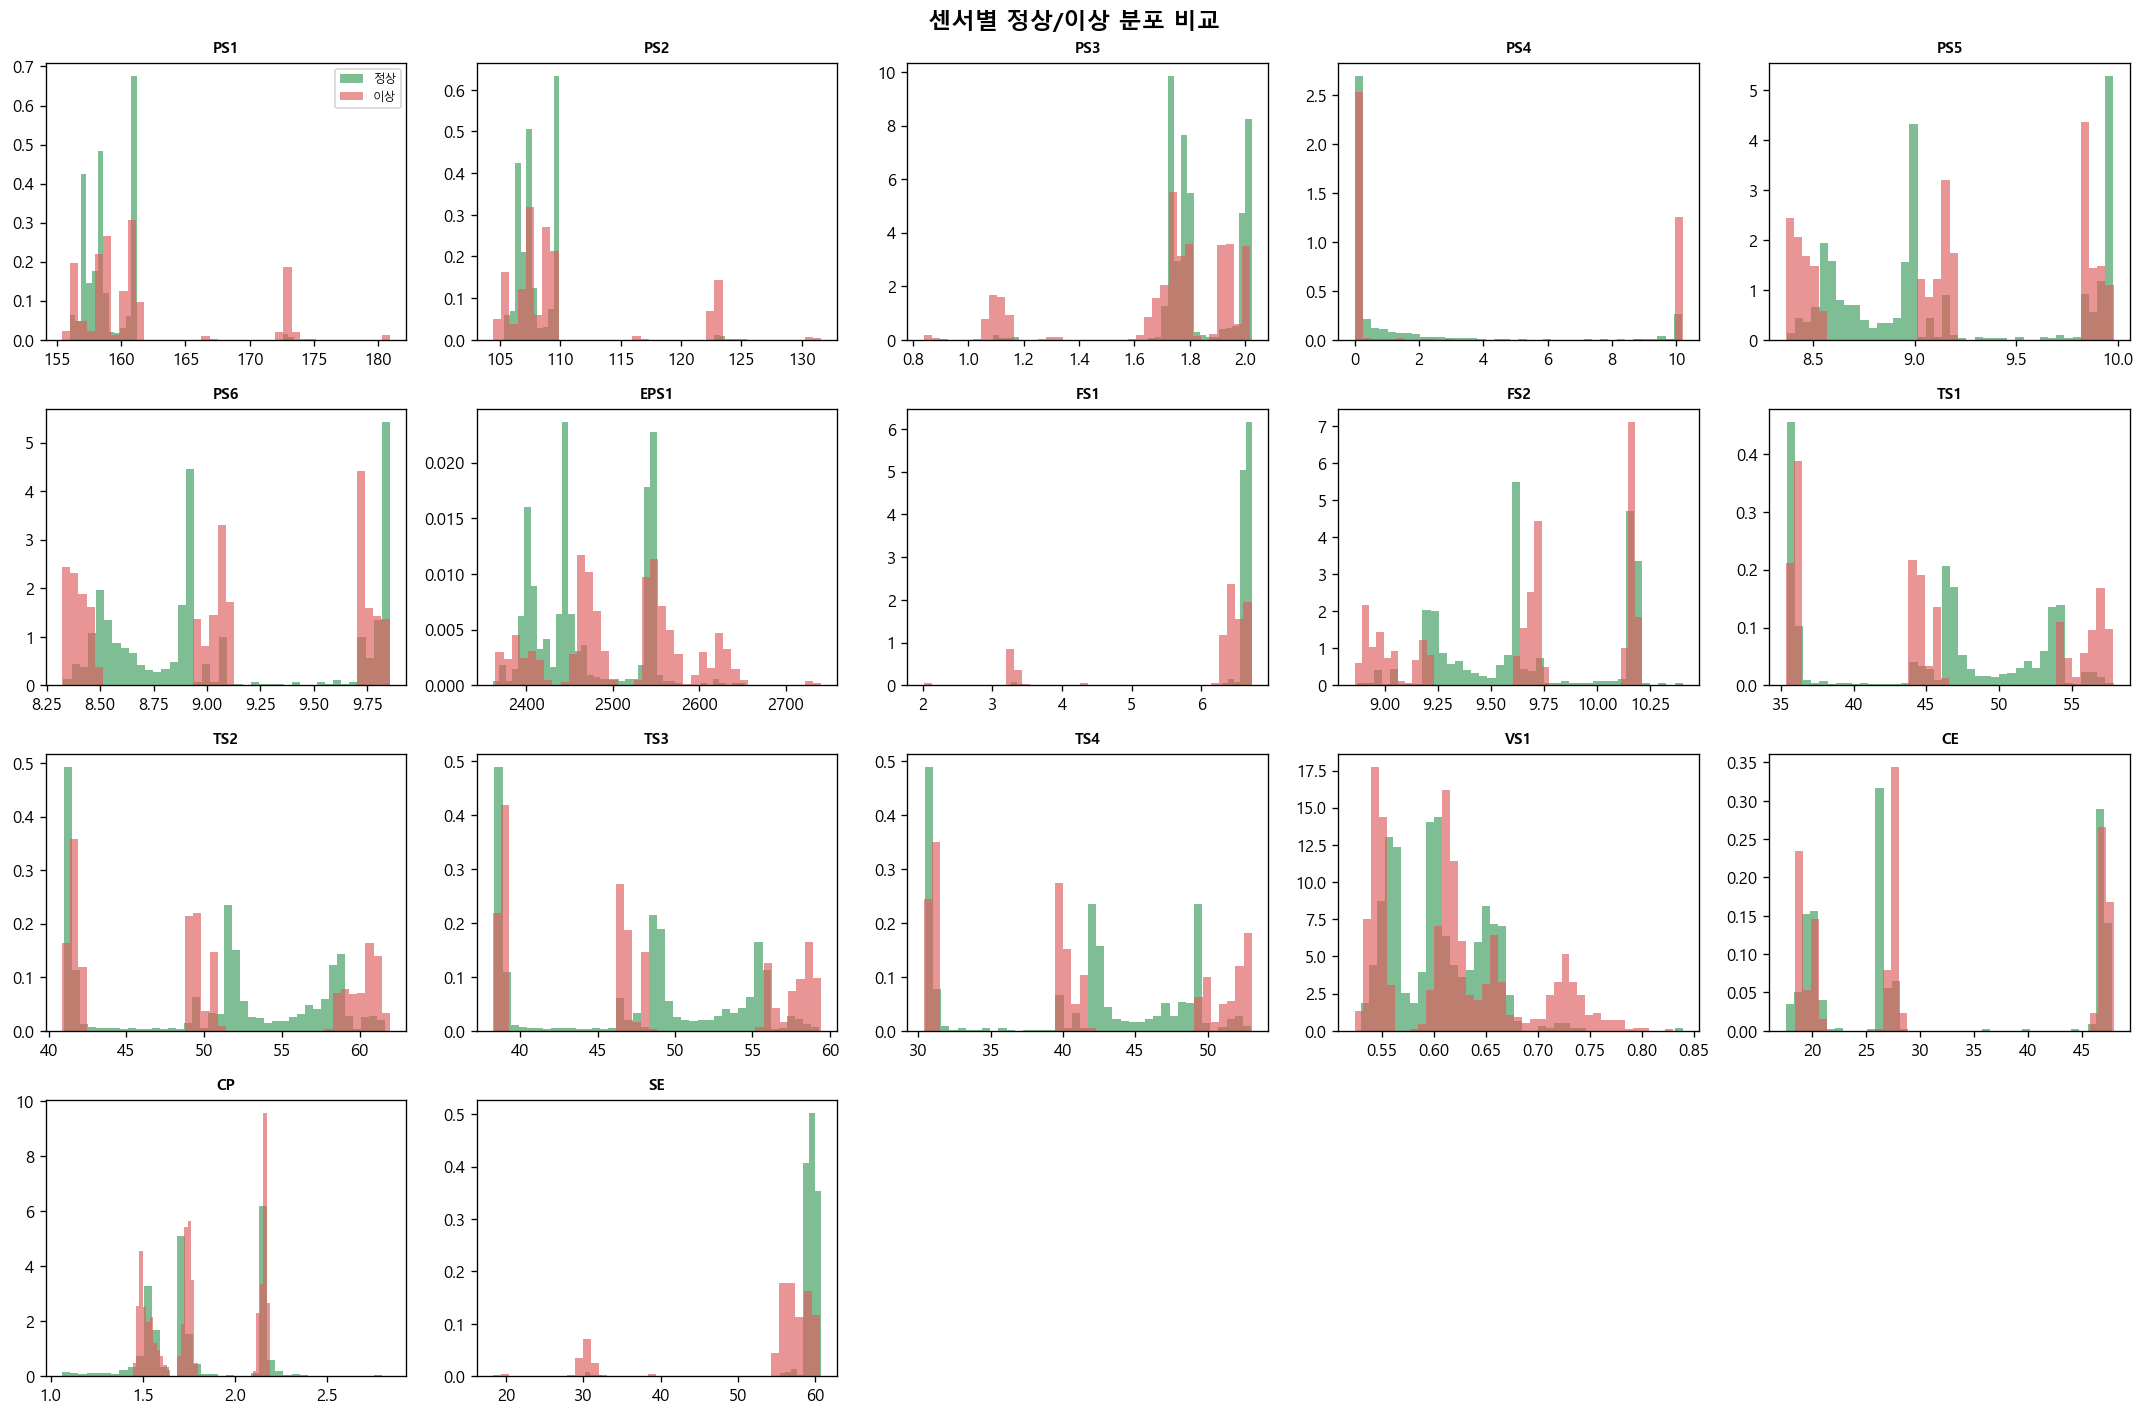

In [5]:
fig, axes = plt.subplots(4, 5, figsize=(18, 12))
axes_flat = axes.ravel()

for i, s in enumerate(SENSORS):
    ax = axes_flat[i]
    normal_vals = df.loc[df.label==0, s]
    anom_vals   = df.loc[df.label==1, s]
    ax.hist(normal_vals, bins=40, color=GREEN, alpha=0.65, label='정상', density=True)
    ax.hist(anom_vals,   bins=40, color=RED,   alpha=0.65, label='이상', density=True)
    ax.set_title(s, fontsize=9, fontweight='bold')
    if i == 0: ax.legend(fontsize=7)

# 사용하지 않는 axes 숨김
for k in range(len(SENSORS), len(axes_flat)):
    axes_flat[k].axis('off')

plt.suptitle('센서별 정상/이상 분포 비교', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 2-4. 학습/검증/테스트 Stratified Split + AE 전처리

=== 데이터 분할 결과 ===
  Train (정상만, AE 학습용):  529개
  Train (전체): 1543개  (이상 1014개)
  Validation:  331개  (이상 217개)
  Test:  331개  (이상 218개)


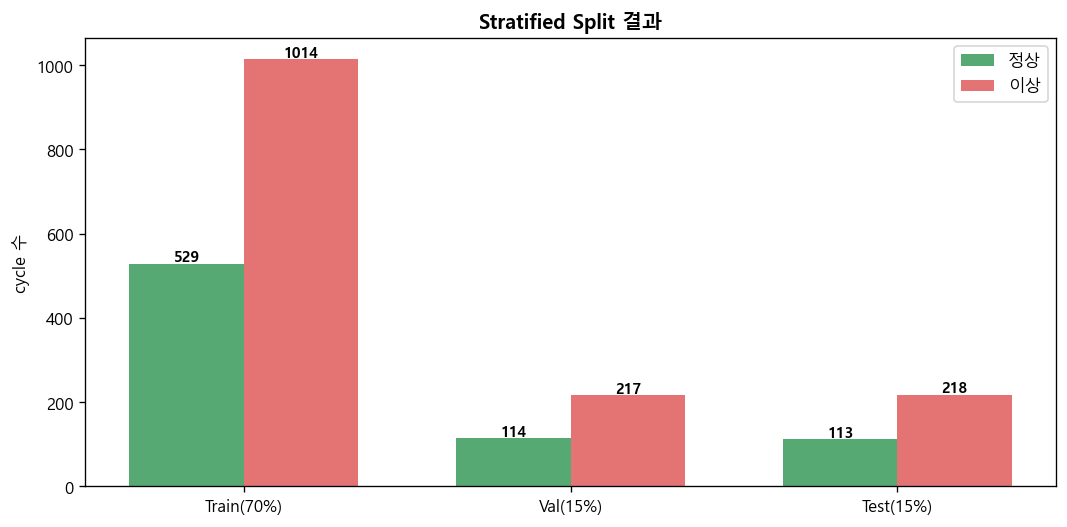

In [6]:
X = df[SENSORS].values.astype(np.float32)
y = df['label'].values.astype(np.float32)

X_tv, X_te, y_tv, y_te = train_test_split(X, y, test_size=0.15,
                                            random_state=SEED, stratify=y)
X_tr, X_va, y_tr, y_va = train_test_split(X_tv, y_tv, test_size=0.15/0.85,
                                            random_state=SEED, stratify=y_tv)

# AE는 정상 데이터만 학습 (StandardScaler도 정상 train으로만 fit)
normal_mask = y_tr == 0
scaler = StandardScaler()
X_tr_n = scaler.fit_transform(X_tr[normal_mask])
X_va_s = scaler.transform(X_va)
X_te_s = scaler.transform(X_te)

print('=== 데이터 분할 결과 ===')
for name, X_, y_ in [('Train (정상만, AE 학습용)', X_tr_n, None),
                       ('Train (전체)', X_tr, y_tr),
                       ('Validation', X_va, y_va),
                       ('Test', X_te, y_te)]:
    if y_ is not None:
        print(f'  {name}: {len(X_):4d}개  (이상 {int(y_.sum())}개)')
    else:
        print(f'  {name}: {len(X_):4d}개')

# 분할 시각화
fig, ax = plt.subplots(figsize=(9, 4.5))
x_pos = np.arange(3)
w = 0.35
counts_norm = [int((y_tr==0).sum()), int((y_va==0).sum()), int((y_te==0).sum())]
counts_anom = [int(y_tr.sum()), int(y_va.sum()), int(y_te.sum())]
ax.bar(x_pos - w/2, counts_norm, w, label='정상', color=GREEN, alpha=0.85)
ax.bar(x_pos + w/2, counts_anom, w, label='이상', color=RED, alpha=0.85)
for i, (n, a) in enumerate(zip(counts_norm, counts_anom)):
    ax.text(i - w/2, n + 5, str(n), ha='center', fontweight='bold', fontsize=9)
    ax.text(i + w/2, a + 5, str(a), ha='center', fontweight='bold', fontsize=9)
ax.set_xticks(x_pos); ax.set_xticklabels(['Train(70%)','Val(15%)','Test(15%)'])
ax.set_title('Stratified Split 결과', fontweight='bold')
ax.set_ylabel('cycle 수'); ax.legend()
plt.tight_layout(); plt.show()

---
## 03 DenoisingAE 정의 및 학습

In [7]:
class DenoisingAE(nn.Module):
    """HybridPdM models.py의 DenoisingAE와 동일 구조 (BN 포함, 비대칭 capacity)."""
    def __init__(self, input_dim=17, latent_dim=16, noise_std=0.05):
        super().__init__()
        self.noise_std = noise_std
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Linear(32, 16),        nn.BatchNorm1d(16), nn.ReLU(),
            nn.Linear(16, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 24), nn.BatchNorm1d(24), nn.ReLU(),
            nn.Linear(24, 32),         nn.BatchNorm1d(32), nn.ReLU(),
            nn.Linear(32, input_dim),
        )
    def forward(self, x):
        if self.training and self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std
        return self.decoder(self.encoder(x))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')

def train_ae(X_train, X_val, epochs=60, lr=1e-3, batch_size=256, patience=10):
    model = DenoisingAE(input_dim=X_train.shape[1], latent_dim=16).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    crit = nn.MSELoss()
    Xtr_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    Xva_t = torch.tensor(X_val,   dtype=torch.float32).to(device)
    loader = DataLoader(TensorDataset(Xtr_t), batch_size=batch_size, shuffle=True)
    tr_losses, va_losses = [], []
    best_val, best_st, cnt = np.inf, None, 0
    for ep in range(1, epochs+1):
        model.train(); el = []
        for (xb,) in loader:
            pred = model(xb); loss = crit(pred, xb)
            opt.zero_grad(); loss.backward(); opt.step()
            el.append(loss.item())
        model.eval()
        with torch.no_grad():
            vl = crit(model(Xva_t), Xva_t).item()
        tr_losses.append(np.mean(el)); va_losses.append(vl)
        if vl < best_val:
            best_val, best_st, cnt = vl, {k:v.clone() for k,v in model.state_dict().items()}, 0
        else:
            cnt += 1
            if cnt >= patience:
                print(f'Early stop at epoch {ep}'); break
        if ep % 10 == 0:
            print(f'Epoch {ep:3d} | train={np.mean(el):.5f} | val={vl:.5f}')
    model.load_state_dict(best_st)
    return model, tr_losses, va_losses

print('학습 시작...')
model, tr_losses, va_losses = train_ae(X_tr_n, X_va_s, epochs=60, patience=10)

device: cpu
학습 시작...
Epoch  10 | train=0.42720 | val=2.53190
Epoch  20 | train=0.17785 | val=0.85888
Epoch  30 | train=0.09111 | val=0.46163
Epoch  40 | train=0.22314 | val=0.22388
Epoch  50 | train=0.04932 | val=0.13972
Early stop at epoch 60


---
## 04 학습 곡선 & 재구성 오차 분포

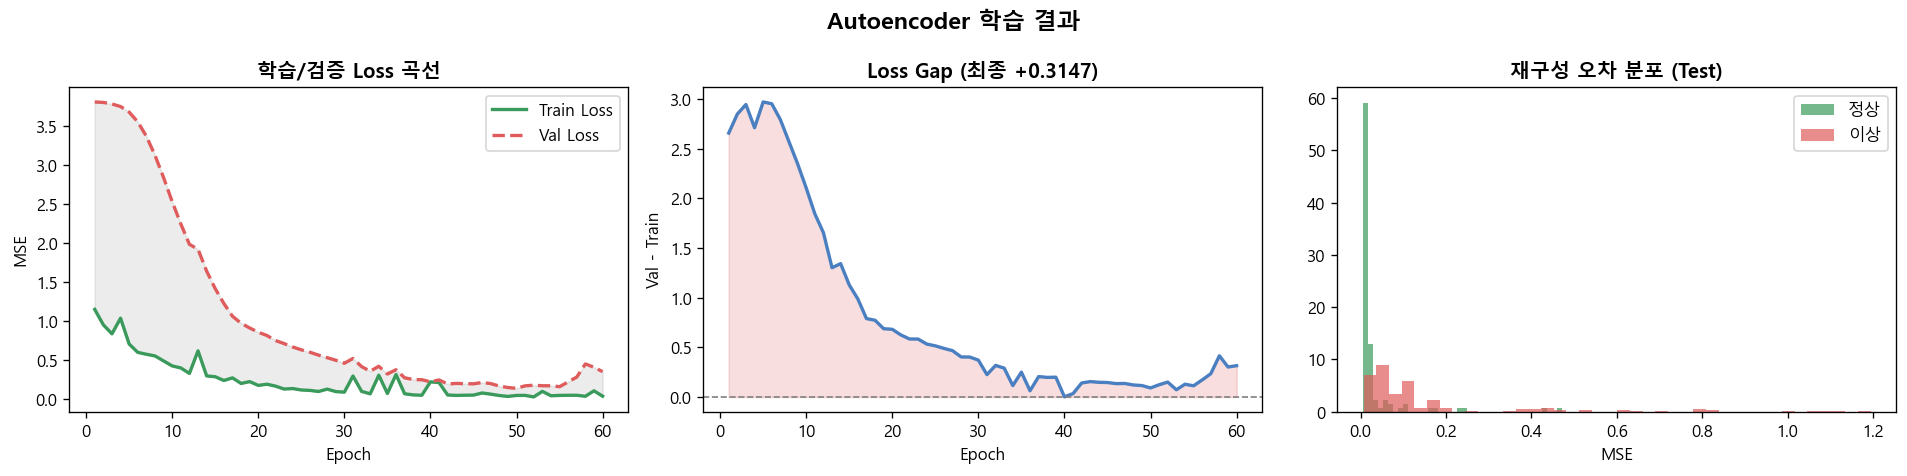

최종 Train: 0.03945  Val: 0.35411  Gap: +0.31466


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ep_range = range(1, len(tr_losses)+1)
gap = np.array(va_losses) - np.array(tr_losses)

ax = axes[0]
ax.plot(ep_range, tr_losses, color=GREEN, linewidth=2, label='Train Loss')
ax.plot(ep_range, va_losses, color=RED,   linewidth=2, label='Val Loss', linestyle='--')
ax.fill_between(ep_range, tr_losses, va_losses, alpha=0.15, color='gray')
ax.set_title('학습/검증 Loss 곡선', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.legend()

ax2 = axes[1]
ax2.plot(ep_range, gap, color=BLUE, linewidth=2)
ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
ax2.fill_between(ep_range, gap, 0, where=(gap<0), alpha=0.2, color=GREEN)
ax2.fill_between(ep_range, gap, 0, where=(gap>0), alpha=0.2, color=RED)
ax2.set_title(f'Loss Gap (최종 {gap[-1]:+.4f})', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val - Train')

model.eval()
with torch.no_grad():
    Xte_t = torch.tensor(X_te_s, dtype=torch.float32).to(device)
    recon = model(Xte_t).cpu().numpy()
mse_te = np.mean((X_te_s - recon)**2, axis=1)

ax3 = axes[2]
ax3.hist(mse_te[y_te==0], bins=40, color=GREEN, alpha=0.7, label='정상', density=True)
ax3.hist(mse_te[y_te==1], bins=40, color=RED,   alpha=0.7, label='이상', density=True)
ax3.set_title('재구성 오차 분포 (Test)', fontweight='bold')
ax3.set_xlabel('MSE'); ax3.legend()

plt.suptitle('Autoencoder 학습 결과', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'최종 Train: {tr_losses[-1]:.5f}  Val: {va_losses[-1]:.5f}  Gap: {gap[-1]:+.5f}')

---
## 05 임계값 percentile grid 탐색

최적 percentile: 80%  threshold=0.02200
  Val F1=0.9091 | Precision=0.8969 | Recall=0.9217


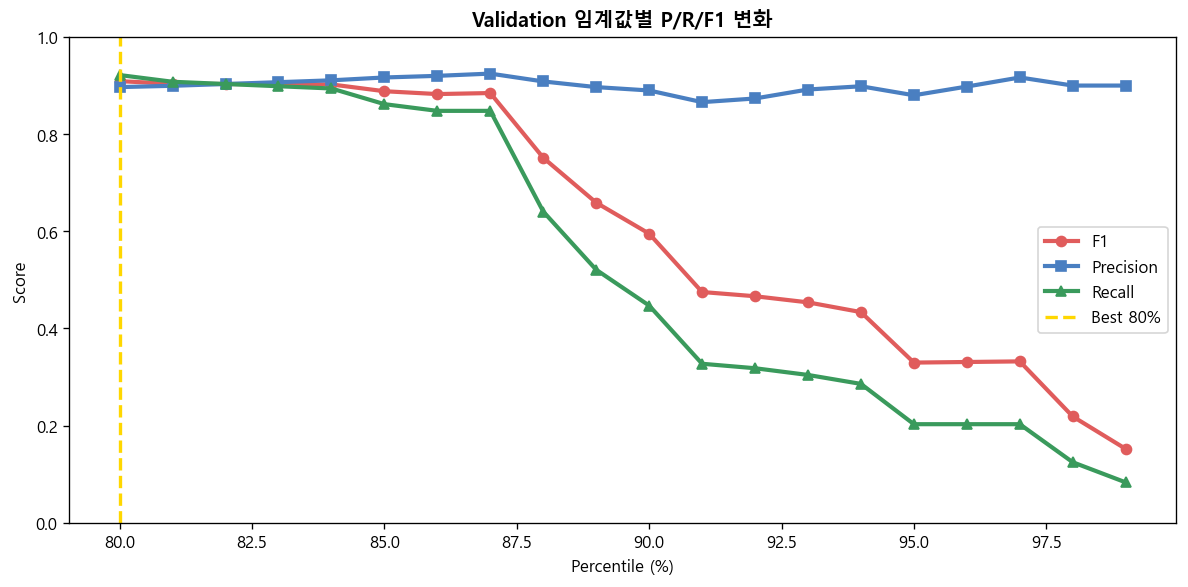

In [9]:
with torch.no_grad():
    Xva_t = torch.tensor(X_va_s, dtype=torch.float32).to(device)
    recon_va = model(Xva_t).cpu().numpy()
mse_va = np.mean((X_va_s - recon_va)**2, axis=1)

pct_grid = list(range(80, 100))
thrs = [np.percentile(mse_va[y_va==0], p) if (y_va==0).any() else np.percentile(mse_va, p)
        for p in pct_grid]
f1s, precs, recs = [], [], []
for thr in thrs:
    yp = (mse_va > thr).astype(int)
    f1s.append(f1_score(y_va, yp, zero_division=0))
    precs.append(precision_score(y_va, yp, zero_division=0))
    recs.append(recall_score(y_va, yp, zero_division=0))

best_idx = int(np.argmax(f1s))
best_pct, best_thr = pct_grid[best_idx], thrs[best_idx]
print(f'최적 percentile: {best_pct}%  threshold={best_thr:.5f}')
print(f'  Val F1={f1s[best_idx]:.4f} | Precision={precs[best_idx]:.4f} | Recall={recs[best_idx]:.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pct_grid, f1s,   color=RED,   linewidth=2.5, marker='o', label='F1')
ax.plot(pct_grid, precs, color=BLUE,  linewidth=2.5, marker='s', label='Precision')
ax.plot(pct_grid, recs,  color=GREEN, linewidth=2.5, marker='^', label='Recall')
ax.axvline(best_pct, color='gold', linewidth=2, linestyle='--', label=f'Best {best_pct}%')
ax.set_xlabel('Percentile (%)'); ax.set_ylabel('Score'); ax.set_ylim(0, 1)
ax.set_title('Validation 임계값별 P/R/F1 변화', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

---
## 06 최종 모델 성능 (Test Set)

=== 최종 성능 (Test) ===
  AUC=0.8902  F1=0.8802  Precision=0.8843  Recall=0.8761


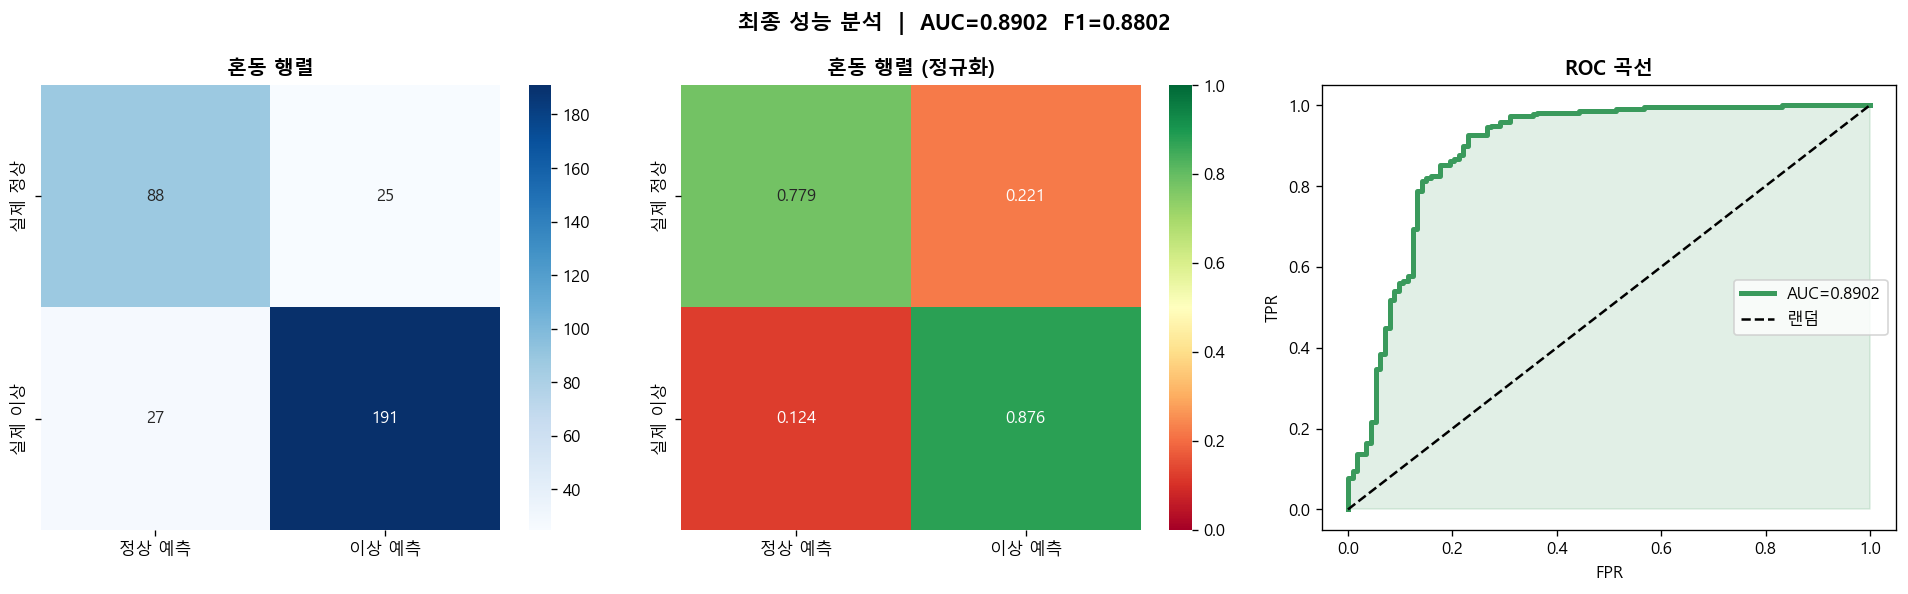

In [10]:
y_pred_te = (mse_te > best_thr).astype(int)
y_true_te = y_te.astype(int)

f1_final   = f1_score(y_true_te, y_pred_te, zero_division=0)
prec_final = precision_score(y_true_te, y_pred_te, zero_division=0)
rec_final  = recall_score(y_true_te, y_pred_te, zero_division=0)
auc_final  = roc_auc_score(y_true_te, mse_te)

print('=== 최종 성능 (Test) ===')
print(f'  AUC={auc_final:.4f}  F1={f1_final:.4f}  Precision={prec_final:.4f}  Recall={rec_final:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cm = confusion_matrix(y_true_te, y_pred_te)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['정상 예측','이상 예측'], yticklabels=['실제 정상','실제 이상'])
axes[0].set_title('혼동 행렬', fontweight='bold')

cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_n, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[1], vmin=0, vmax=1,
            xticklabels=['정상 예측','이상 예측'], yticklabels=['실제 정상','실제 이상'])
axes[1].set_title('혼동 행렬 (정규화)', fontweight='bold')

fpr_c, tpr_c, _ = roc_curve(y_true_te, mse_te)
axes[2].plot(fpr_c, tpr_c, color=GREEN, linewidth=3, label=f'AUC={auc_final:.4f}')
axes[2].plot([0,1],[0,1], 'k--', linewidth=1.5, label='랜덤')
axes[2].fill_between(fpr_c, tpr_c, alpha=0.15, color=GREEN)
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('ROC 곡선', fontweight='bold'); axes[2].legend()

plt.suptitle(f'최종 성능 분석  |  AUC={auc_final:.4f}  F1={f1_final:.4f}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 07 센서별 재구성 오차 기여도 분석
어느 센서의 재구성 오차가 가장 컸는지 → 결함 진단의 단서가 된다.

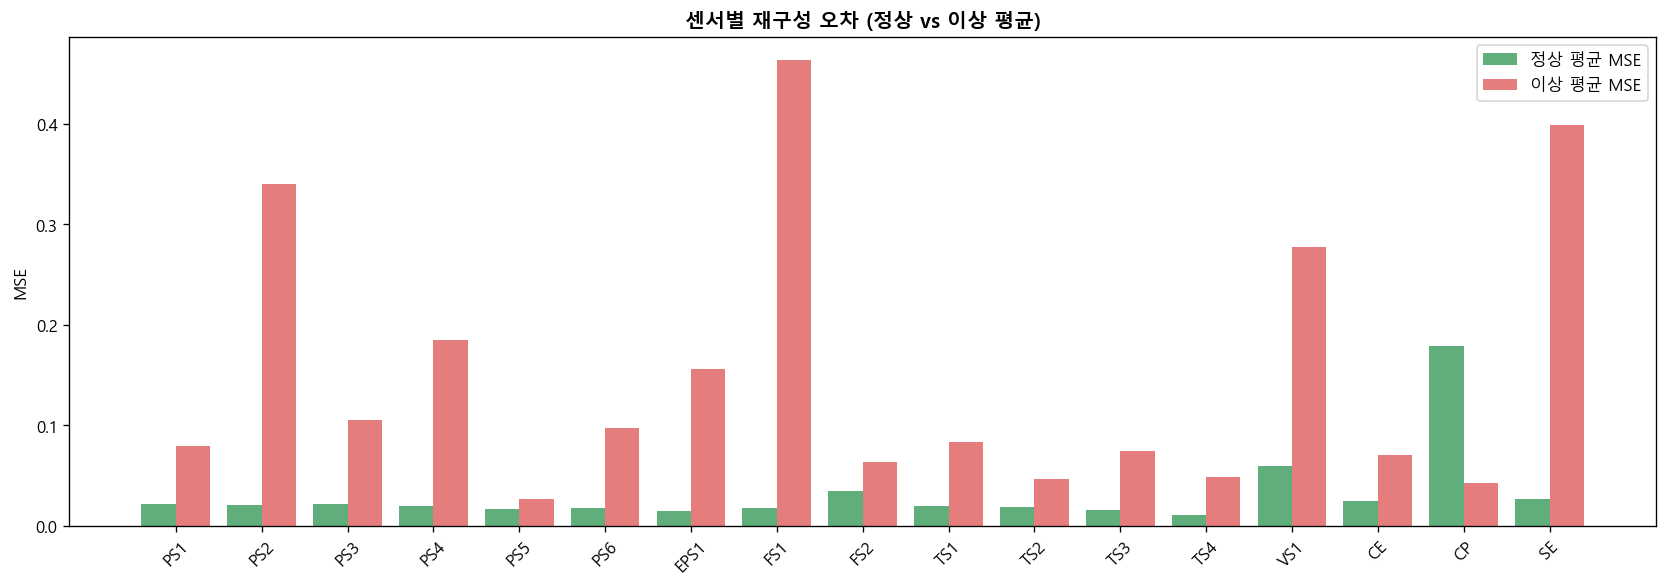

[이상 cycle에서 재구성 오차 비율이 큰 Top-5 센서]
  1. FS1: 비율 26.61× (정상 0.017 → 이상 0.463)
  2. PS2: 비율 16.90× (정상 0.020 → 이상 0.340)
  3. SE: 비율 14.74× (정상 0.027 → 이상 0.399)
  4. EPS1: 비율 10.41× (정상 0.015 → 이상 0.156)
  5. PS4: 비율 9.24× (정상 0.020 → 이상 0.185)


In [11]:
# 센서별 재구성 오차 (테스트 - 이상 cycle만)
anom_mask = y_te == 1
per_sensor_err = ((X_te_s[anom_mask] - recon[anom_mask])**2).mean(axis=0)
per_sensor_norm = ((X_te_s[~anom_mask] - recon[~anom_mask])**2).mean(axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(SENSORS))
w = 0.4
ax.bar(x - w/2, per_sensor_norm, w, color=GREEN, alpha=0.8, label='정상 평균 MSE')
ax.bar(x + w/2, per_sensor_err,  w, color=RED,   alpha=0.8, label='이상 평균 MSE')
ax.set_xticks(x); ax.set_xticklabels(SENSORS, rotation=45)
ax.set_title('센서별 재구성 오차 (정상 vs 이상 평균)', fontweight='bold')
ax.set_ylabel('MSE'); ax.legend()
plt.tight_layout(); plt.show()

# Top-5 기여 센서
ratio = per_sensor_err / (per_sensor_norm + 1e-9)
top5_idx = np.argsort(-ratio)[:5]
print('[이상 cycle에서 재구성 오차 비율이 큰 Top-5 센서]')
for r, idx in enumerate(top5_idx, 1):
    print(f'  {r}. {SENSORS[idx]}: 비율 {ratio[idx]:.2f}× (정상 {per_sensor_norm[idx]:.3f} → 이상 {per_sensor_err[idx]:.3f})')

---
## 07-bis 신규 모델 비교 — LSTM-AE (실패 사례, Phase 1)

Dense AE는 cycle당 평균값 1개로 압축하지만, LSTM-AE는 cycle 내 60 timesteps의 시계열을 보존한다.
**예상:** LSTM-AE가 시간 패턴을 학습하여 +3~5% F1 향상
**실제:** F1 0.896 → 0.605 (29%p **악화**)

왜 시간 정보 추가가 성능 저하로 이어졌는지 분석한다.

In [ ]:
# ── LSTM-AE 학습용 데이터 준비 (60 timesteps × 17 sensors) ───
# 모든 센서를 1Hz로 통일하여 다운샘플:
#   100Hz (PS1-6, EPS1): 100개 평균 → 60 timesteps
#   10Hz  (FS1-2)       :  10개 평균 → 60 timesteps
#   1Hz   (TS1-4, VS1, CE, CP, SE) : 그대로
SEQ_LEN = 60
sensor_seq = []
for s in SENSORS:
    arr = np.loadtxt(DATA_DIR / f'{s}.txt')
    if arr.ndim == 1: arr = arr.reshape(-1, 1)
    n_cycles, n_per = arr.shape
    if n_per == SEQ_LEN:
        ds = arr.astype(np.float32)
    else:
        factor = n_per // SEQ_LEN
        ds = arr.reshape(n_cycles, SEQ_LEN, factor).mean(axis=2).astype(np.float32)
    sensor_seq.append(ds)
X_seq = np.stack(sensor_seq, axis=2).astype(np.float32)   # (2205, 60, 17)
print(f'LSTM-AE 입력 shape: {X_seq.shape}')

# 동일한 stratified split (seed 일치)
from sklearn.model_selection import train_test_split
Xseq_tv, Xseq_te, y_tvs, y_tes = train_test_split(
    X_seq, df['label'].values.astype(np.float32),
    test_size=0.15, random_state=SEED, stratify=df['label'].values,
)
Xseq_tr, Xseq_va, y_trs, y_vas = train_test_split(
    Xseq_tv, y_tvs, test_size=0.15/0.85, random_state=SEED, stratify=y_tvs,
)
norm_mask = y_trs == 0
Xseq_tr_n = Xseq_tr[norm_mask]

# 채널별 z-score (정상 train으로만 fit)
mu = Xseq_tr_n.reshape(-1, 17).mean(axis=0)
sd = Xseq_tr_n.reshape(-1, 17).std(axis=0) + 1e-6
def norm(x): return ((x - mu) / sd).astype(np.float32)
Xseq_tr_n, Xseq_va_n, Xseq_te_n = norm(Xseq_tr_n), norm(Xseq_va), norm(Xseq_te)
print(f'정상 train (LSTM-AE 학습용): {Xseq_tr_n.shape[0]}개 cycle')

In [ ]:
# ── LSTMAutoencoder 정의 + 학습 ──────────────────────────────
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, seq_len, hidden=64, latent=16):
        super().__init__()
        self.seq_len = seq_len
        self.enc = nn.LSTM(n_features, hidden, batch_first=True, bidirectional=True)
        self.proj = nn.Linear(hidden * 2, latent)
        self.dec = nn.LSTM(latent, hidden, batch_first=True)
        self.out = nn.Linear(hidden, n_features)
    def forward(self, x):
        out, _ = self.enc(x)
        z = self.proj(out.mean(dim=1))                 # (B, latent)
        z_seq = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        dec, _ = self.dec(z_seq)
        return self.out(dec)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_lstm = LSTMAutoencoder(17, SEQ_LEN, 64, 16).to(device)
opt = torch.optim.Adam(model_lstm.parameters(), lr=1e-3, weight_decay=1e-5)
crit = nn.MSELoss()
Xtr_t = torch.tensor(Xseq_tr_n, dtype=torch.float32).to(device)
Xva_t = torch.tensor(Xseq_va_n, dtype=torch.float32).to(device)
loader = DataLoader(TensorDataset(Xtr_t), batch_size=64, shuffle=True)

best_val, cnt = np.inf, 0
for ep in range(1, 41):
    model_lstm.train(); el = []
    for (xb,) in loader:
        pred = model_lstm(xb)
        loss = crit(pred, xb)
        opt.zero_grad(); loss.backward(); opt.step()
        el.append(loss.item())
    model_lstm.eval()
    with torch.no_grad():
        vl = crit(model_lstm(Xva_t), Xva_t).item()
    if vl < best_val: best_val, cnt = vl, 0
    else:
        cnt += 1
        if cnt >= 10: break
    if ep % 10 == 0:
        print(f'Epoch {ep:3d}  train={np.mean(el):.4f}  val={vl:.4f}')

# 평가: 재구성 오차 → percentile threshold
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
model_lstm.eval()
with torch.no_grad():
    Xte_t = torch.tensor(Xseq_te_n, dtype=torch.float32).to(device)
    recon_te = model_lstm(Xte_t).cpu().numpy()
    Xva_t2 = torch.tensor(Xseq_va_n, dtype=torch.float32).to(device)
    recon_va_l = model_lstm(Xva_t2).cpu().numpy()
mse_te_l  = ((Xseq_te_n - recon_te)**2).mean(axis=(1, 2))
mse_va_l  = ((Xseq_va_n - recon_va_l)**2).mean(axis=(1, 2))

# val grid (정상-only percentile)
mse_va_norm = mse_va_l[y_vas == 0]
best_f1, best_thr_lstm = -1, 0
for p in range(70, 100):
    thr = np.percentile(mse_va_norm, p)
    f1v = f1_score(y_vas, (mse_va_l > thr).astype(int), zero_division=0)
    if f1v > best_f1: best_f1, best_thr_lstm = f1v, thr
y_pred_lstm = (mse_te_l > best_thr_lstm).astype(int)
f1_lstm = f1_score(y_tes.astype(int), y_pred_lstm, zero_division=0)
print(f'\nLSTM-AE Test F1 = {f1_lstm:.4f}')
print(f'Dense AE 본문 F1 = {f1_final:.4f}')

### 왜 LSTM-AE가 Dense AE보다 약했는가?

1. **시간 정보 가설 빗나감** — Hydraulic의 cycle 내 패턴은 단순한 평균값으로도 충분히 캡처됨
2. **1Hz 다운샘플의 정보 손실** — 100Hz 센서(PS, EPS) 의 빠른 변동(스파이크, 진동)이 60개 평균으로 압축되며 사라짐
3. **Encoder 표현력 제한** — 시퀀스 평균 pooling 으로 latent 추출 → 결국 Dense AE 와 비슷한 정보, 학습 부담만 증가
4. **학습 데이터 부족** — 정상 train 1500개 수준은 LSTM 학습에는 적은 양

**결론:** 해당 도메인에서는 **"더 복잡한 모델 = 더 좋은 성능" 가설이 성립하지 않는다.** Dense AE가 충분히 강력한 baseline.

In [ ]:
# ── Dense AE vs LSTM-AE 시각 비교 ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
labels = ['Dense AE\n(cycle 평균, 17 → 11)', 'LSTM-AE\n(60 timesteps × 17)']
values = [f1_final, f1_lstm]
colors_v = [GREEN, RED]
bars = ax.bar(labels, values, color=colors_v, edgecolor='white', linewidth=1.5)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.015,
            f'{v:.4f}', ha='center', fontweight='bold', fontsize=13)
ax.set_ylim(0, max(values) * 1.3)
ax.set_ylabel('F1-Score (Test)')
ax.set_title('Hydraulic — Dense AE vs LSTM-AE', fontweight='bold')
ax.text(0.5, 0.92, f'Δ F1 = {(f1_lstm - f1_final)*100:+.1f}%p',
        transform=ax.transAxes, fontsize=13, fontweight='bold',
        ha='center', color='red' if f1_lstm < f1_final else 'green')
plt.tight_layout(); plt.show()
print('[권장] 본 데이터에서는 Dense AE 유지. LSTM-AE는 실험 기록으로만 보존.')

---
## 09 종합 요약

In [12]:
print('=' * 60)
print('UCI Hydraulic Condition - DenoisingAE 이상 탐지 요약')
print('=' * 60)
print(f'\n[데이터셋]')
print(f'  총 cycle: {n_total:,}개  (정상 {n_normal} / 이상 {n_anom})')
print(f'  센서 수: 17개 (압력 6 + 전력 1 + 유량 2 + 온도 4 + 진동/효율 4)')
print(f'  샘플레이트 통일: cycle당 평균값 집계')
print(f'\n[전처리]')
print(f'  Stratified Split: Train 70% / Val 15% / Test 15%')
print(f'  StandardScaler (정상 train으로만 fit)')
print(f'  AE 학습 데이터: 정상 {len(X_tr_n)}개')
print(f'\n[모델 구조]')
print(f'  Encoder: 17 → 32(BN) → 16(BN) → 16(latent)')
print(f'  Decoder: 16 → 24(BN) → 32(BN) → 17')
print(f'  Noise: σ=0.05 (denoising)')
print(f'  학습: {len(tr_losses)} epoch (Early Stopping)')
print(f'\n[최종 성능]')
print(f'  AUC:       {auc_final:.4f}')
print(f'  F1-Score:  {f1_final:.4f}')
print(f'  Precision: {prec_final:.4f}')
print(f'  Recall:    {rec_final:.4f}')
print(f'  최적 임계값 percentile: {best_pct}%')
print(f'\n[주요 인사이트]')
print(f'  - profile.txt의 stable_flag만 사용 (cooler/valve/pump/hydraulic 4종 결함 모두 포함)')
print(f'  - cycle당 평균 집계로 17→1행 단순화 (시계열 정보 손실 있음 → CNN-AE 확장 가능)')
print(f'  - Mahalanobis 보조 점수로 추가 개선 가능 (combined_score)')
print('=' * 60)

UCI Hydraulic Condition - DenoisingAE 이상 탐지 요약

[데이터셋]
  총 cycle: 2,205개  (정상 756 / 이상 1449)
  센서 수: 17개 (압력 6 + 전력 1 + 유량 2 + 온도 4 + 진동/효율 4)
  샘플레이트 통일: cycle당 평균값 집계

[전처리]
  Stratified Split: Train 70% / Val 15% / Test 15%
  StandardScaler (정상 train으로만 fit)
  AE 학습 데이터: 정상 529개

[모델 구조]
  Encoder: 17 → 32(BN) → 16(BN) → 16(latent)
  Decoder: 16 → 24(BN) → 32(BN) → 17
  Noise: σ=0.05 (denoising)
  학습: 60 epoch (Early Stopping)

[최종 성능]
  AUC:       0.8902
  F1-Score:  0.8802
  Precision: 0.8843
  Recall:    0.8761
  최적 임계값 percentile: 80%

[주요 인사이트]
  - profile.txt의 stable_flag만 사용 (cooler/valve/pump/hydraulic 4종 결함 모두 포함)
  - cycle당 평균 집계로 17→1행 단순화 (시계열 정보 손실 있음 → CNN-AE 확장 가능)
  - Mahalanobis 보조 점수로 추가 개선 가능 (combined_score)
